In [ ]:
# ─────────────────────────────────────────────────────────────
# Core
# ─────────────────────────────────────────────────────────────
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
# ML
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack

import joblib

# ─────────────────────────────────────────────────────────────
# Boosting Libraries
# ─────────────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed")

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not installed")

# ─────────────────────────────────────────────────────────────
# Settings
# ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TFIDF_MAX_FEATURES = 50000

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

print("✅ Setup complete")

✅ Setup complete


In [ ]:
FAKE_CSV_PATH = "Fake.csv"
TRUE_CSV_PATH = "True.csv"

LABEL_COL   = "label"
CLASS_NAMES = {0: "FAKE", 1: "REAL"}


def load_dataset(fake_path, true_path):
    # Safety check
    if not Path(fake_path).exists() or not Path(true_path).exists():
        raise FileNotFoundError("Fake.csv or True.csv not found")

    fake_df = pd.read_csv(fake_path)
    true_df = pd.read_csv(true_path)

    fake_df[LABEL_COL] = 0
    true_df[LABEL_COL] = 1

    df = pd.concat([fake_df, true_df], ignore_index=True)

    # Shuffle
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    return df


# ─────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────
df = load_dataset(FAKE_CSV_PATH, TRUE_CSV_PATH)

# Fill missing safely
df["title"] = df["title"].fillna("")
df["text"]  = df["text"].fillna("")

# Combine title + text
df["content"] = df["title"] + " " + df["text"]

TEXT_COL = "content"

# ─────────────────────────────────────────────────────────────
# CLEANING FUNCTION
# ─────────────────────────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()

    # Remove dataset bias (MOST IMPORTANT)
    text = re.sub(r"\(reuters\)", " ", text)
    text = re.sub(r"\breuters\b", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# Apply cleaning
df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

# ─────────────────────────────────────────────────────────────
# REMOVE DUPLICATES
# ─────────────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
after = len(df)

# ─────────────────────────────────────────────────────────────
# REPORT
# ─────────────────────────────────────────────────────────────
print(f"Data shape: {df.shape}")
print(f"Duplicates removed: {before - after}")

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts(normalize=True))

Data shape: (39096, 6)
Duplicates removed: 5802

Label distribution:
label
1    0.542127
0    0.457873
Name: proportion, dtype: float64


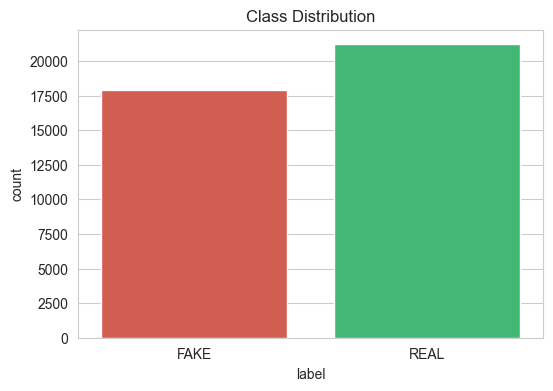

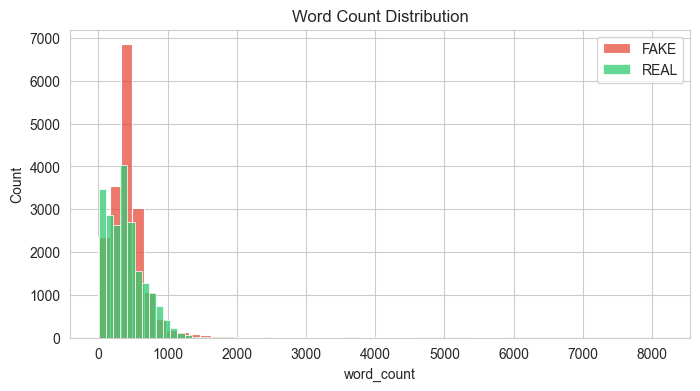

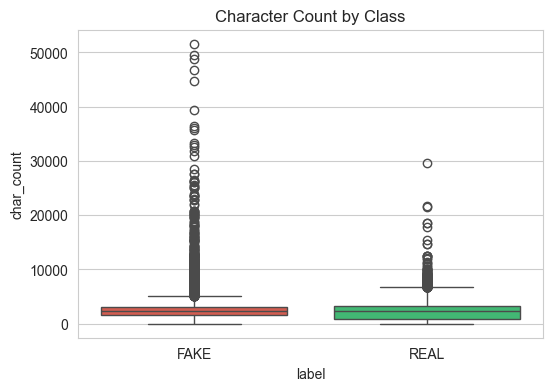

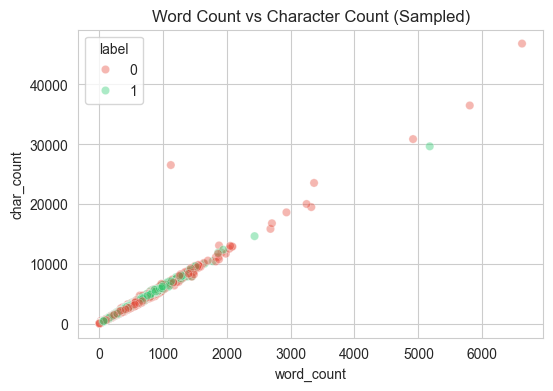

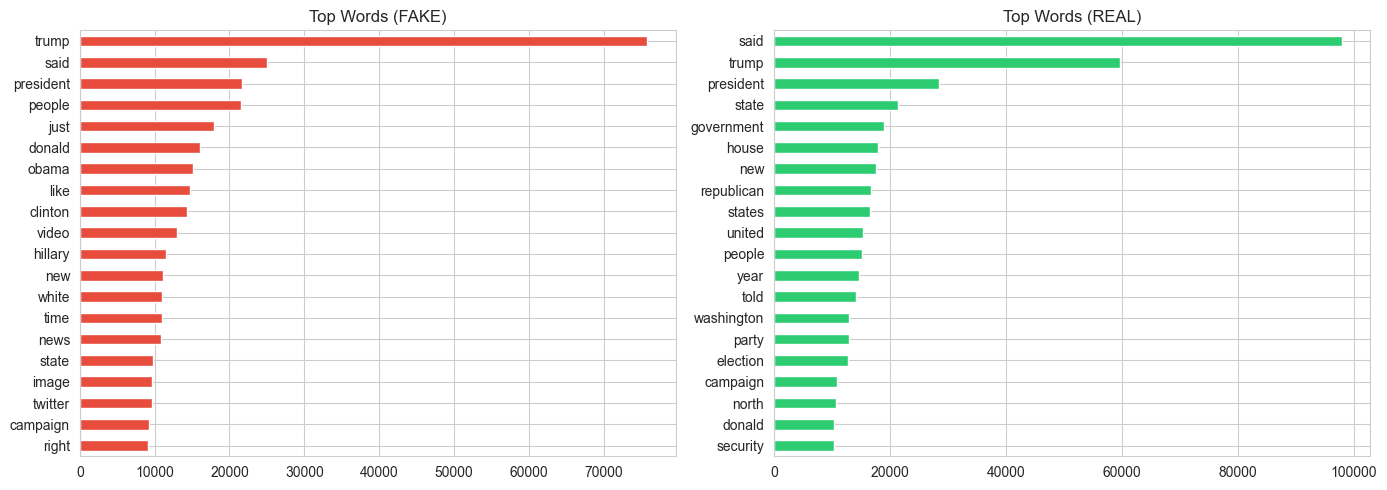

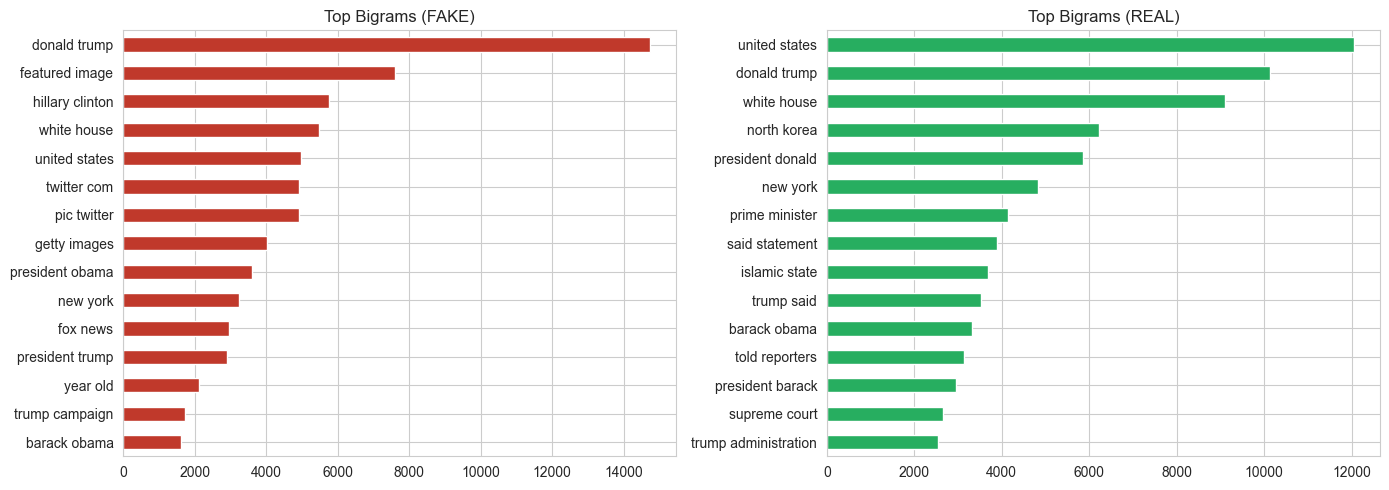

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")

# ─────────────────────────────────────────────────────────────
# BASIC STATS
# ─────────────────────────────────────────────────────────────
df["word_count"] = df[TEXT_COL].apply(lambda x: len(str(x).split()))
df["char_count"] = df[TEXT_COL].apply(len)

FAKE_MASK = df[LABEL_COL] == 0
REAL_MASK = df[LABEL_COL] == 1

# ─────────────────────────────────────────────────────────────
# 1. CLASS DISTRIBUTION
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x=LABEL_COL, data=df, palette=["#e74c3c", "#2ecc71"])
plt.title("Class Distribution")
plt.xticks([0, 1], ["FAKE", "REAL"])
plt.show()

# ─────────────────────────────────────────────────────────────
# 2. WORD COUNT DISTRIBUTION (FIXED)
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df.loc[FAKE_MASK, "word_count"], label="FAKE", bins=50, kde=False, color="#e74c3c")
sns.histplot(df.loc[REAL_MASK, "word_count"], label="REAL", bins=50, kde=False, color="#2ecc71")
plt.title("Word Count Distribution")
plt.legend()
plt.show()

# ─────────────────────────────────────────────────────────────
# 3. CHARACTER COUNT BOXPLOT
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[LABEL_COL], y=df["char_count"], palette=["#e74c3c", "#2ecc71"])
plt.title("Character Count by Class")
plt.xticks([0, 1], ["FAKE", "REAL"])
plt.show()

# ─────────────────────────────────────────────────────────────
# 4. WORD vs CHARACTER (DOWNSAMPLED)
# ─────────────────────────────────────────────────────────────
sample_df = df.sample(n=5000, random_state=RANDOM_STATE)

plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=sample_df["word_count"],
    y=sample_df["char_count"],
    hue=sample_df[LABEL_COL],
    palette=["#e74c3c", "#2ecc71"],
    alpha=0.4
)
plt.title("Word Count vs Character Count (Sampled)")
plt.show()

# ─────────────────────────────────────────────────────────────
# 5. TOP WORDS (OPTIMIZED)
# ─────────────────────────────────────────────────────────────
def get_top_words(corpus, n=20):
    vec = CountVectorizer(stop_words="english", max_features=10000)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    words = vec.get_feature_names_out()
    return pd.Series(counts, index=words).sort_values(ascending=False).head(n)

fake_top = get_top_words(df.loc[FAKE_MASK, TEXT_COL])
real_top = get_top_words(df.loc[REAL_MASK, TEXT_COL])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_top[::-1].plot(kind="barh", ax=axes[0], color="#e74c3c")
axes[0].set_title("Top Words (FAKE)")

real_top[::-1].plot(kind="barh", ax=axes[1], color="#2ecc71")
axes[1].set_title("Top Words (REAL)")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 6. BIGRAMS (OPTIMIZED)
# ─────────────────────────────────────────────────────────────
def get_top_bigrams(corpus, n=15):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=10000)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    words = vec.get_feature_names_out()
    return pd.Series(counts, index=words).sort_values(ascending=False).head(n)

fake_bi = get_top_bigrams(df.loc[FAKE_MASK, TEXT_COL])
real_bi = get_top_bigrams(df.loc[REAL_MASK, TEXT_COL])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_bi[::-1].plot(kind="barh", ax=axes[0], color="#c0392b")
axes[0].set_title("Top Bigrams (FAKE)")

real_bi[::-1].plot(kind="barh", ax=axes[1], color="#27ae60")
axes[1].set_title("Top Bigrams (REAL)")

plt.tight_layout()
plt.show()

In [4]:
# ─────────────────────────────────────────────────────────────
# SPLIT DATA
# ─────────────────────────────────────────────────────────────
X = df[TEXT_COL]
y = df[LABEL_COL]

# ── Test split (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

# ── Validation split (15% of total → 0.1765 of remaining)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# ── Reset indices (IMPORTANT)
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# ── Basic info
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

# ── Sanity check: label distribution
print("\nLabel distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\nLabel distribution (Val):")
print(y_val.value_counts(normalize=True))

print("\nLabel distribution (Test):")
print(y_test.value_counts(normalize=True))

print("\n✅ Splits ready (no leakage, balanced)")

Train: (27365,)
Val  : (5866,)
Test : (5865,)

Label distribution (Train):
label
1    0.542116
0    0.457884
Name: proportion, dtype: float64

Label distribution (Val):
label
1    0.542107
0    0.457893
Name: proportion, dtype: float64

Label distribution (Test):
label
1    0.542199
0    0.457801
Name: proportion, dtype: float64

✅ Splits ready (no leakage, balanced)


In [5]:
# ─────────────────────────────────────────────────────────────
# SIMPLE + CONSISTENT + SAFE PREPROCESSING (FIXED)
# ─────────────────────────────────────────────────────────────

import re

RE_SPACE = re.compile(r"\s+")

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove dataset bias
    text = re.sub(r"\(reuters\)", " ", text)
    text = re.sub(r"\breuters\b", " ", text)

    # Normalize whitespace
    text = RE_SPACE.sub(" ", text)

    return text.strip()


# ─────────────────────────────────────────────────────────────
# SAFE APPLICATION (X + y TOGETHER)
# ─────────────────────────────────────────────────────────────

# Train
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
}).reset_index(drop=True)

train_df["text"] = train_df["text"].apply(preprocess_text)

X_train_clean = train_df["text"]
y_train       = train_df["label"]


# Validation
val_df = pd.DataFrame({
    "text": X_val,
    "label": y_val
}).reset_index(drop=True)

val_df["text"] = val_df["text"].apply(preprocess_text)

X_val_clean = val_df["text"]
y_val       = val_df["label"]


# Test
test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
}).reset_index(drop=True)

test_df["text"] = test_df["text"].apply(preprocess_text)

X_test_clean = test_df["text"]
y_test       = test_df["label"]


print("✅ Clean preprocessing done (aligned)")
print("Train:", len(X_train_clean), len(y_train))
print("Val  :", len(X_val_clean), len(y_val))
print("Test :", len(X_test_clean), len(y_test))

✅ Clean preprocessing done (aligned)
Train: 27365 27365
Val  : 5866 5866
Test : 5865 5865


In [ ]:
from scipy.sparse import hstack
import time

# ─────────────────────────────────────────────────────────────
# WORD TF-IDF (MAIN SIGNAL)
# ─────────────────────────────────────────────────────────────
tfidf_word = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=50000,
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode",
    dtype=np.float32
)

# ─────────────────────────────────────────────────────────────
# CHAR TF-IDF (STYLE + ROBUSTNESS SIGNAL)
# ─────────────────────────────────────────────────────────────
tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    max_features=30000,
    dtype=np.float32
)

t0 = time.time()

# Fit on TRAIN ONLY
X_train_word = tfidf_word.fit_transform(X_train_clean)
X_val_word   = tfidf_word.transform(X_val_clean)
X_test_word  = tfidf_word.transform(X_test_clean)

X_train_char = tfidf_char.fit_transform(X_train_clean)
X_val_char   = tfidf_char.transform(X_val_clean)
X_test_char  = tfidf_char.transform(X_test_clean)

# Combine
X_train_final = hstack([X_train_word, X_train_char])
X_val_final   = hstack([X_val_word, X_val_char])
X_test_final  = hstack([X_test_word, X_test_char])

print(f"TF-IDF done in {time.time() - t0:.1f}s")

print("\nFeature shapes:")
print("Train:", X_train_final.shape)
print("Val  :", X_val_final.shape)
print("Test :", X_test_final.shape)

TF-IDF done in 498.2s

Feature shapes:
Train: (27365, 80000)
Val  : (5866, 80000)
Test : (5865, 80000)


In [ ]:
import time
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

results_dict = {}

# ─────────────────────────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────────────────────────
def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X)
    else:
        y_score = y_pred

    try:
        roc = roc_auc_score(y, y_score)
    except:
        roc = 0.5

    return {
        "accuracy": accuracy_score(y, y_pred),
        "f1_weighted": f1_score(y, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y, y_pred, average="macro", zero_division=0),
        "roc_auc": roc,
    }


# ─────────────────────────────────────────────────────────────
# TRAIN + EVAL
# ─────────────────────────────────────────────────────────────
def train_and_eval(name, model, X_tr, y_tr, X_val, y_val):
    t0 = time.time()

    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    val_metrics = evaluate_model(model, X_val, y_val)

    results_dict[name] = {
        "model": model,
        "train_time": train_time,
        **val_metrics
    }

    print(f"{name}")
    print(f"  Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"  F1 (weighted): {val_metrics['f1_weighted']:.4f}")
    print(f"  ROC-AUC      : {val_metrics['roc_auc']:.4f}")
    print(f"  Time         : {train_time:.2f}s\n")


# ─────────────────────────────────────────────────────────────
# MODELS
# ─────────────────────────────────────────────────────────────

#  Logistic Regression (best baseline)
lr = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver="saga",  # better for large sparse
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

train_and_eval("Logistic Regression", lr,
               X_train_final, y_train,
               X_val_final, y_val)


#  Naive Bayes
nb = MultinomialNB(alpha=0.1)

train_and_eval("Naive Bayes", nb,
               X_train_word, y_train,
               X_val_word, y_val)


#  Linear SVM (calibrated)
svm_base = SGDClassifier(
    loss="hinge",
    max_iter=3000,
    alpha=1e-4,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm = CalibratedClassifierCV(svm_base, cv=3)

train_and_eval("Linear SVM", svm,
               X_train_final, y_train,
               X_val_final, y_val)


# ─────────────────────────────────────────────────────────────
# SUMMARY + RANKING
# ─────────────────────────────────────────────────────────────
print("\nBaseline Results")
print("-" * 60)

sorted_models = sorted(results_dict.items(),
                       key=lambda x: x[1]["f1_weighted"],
                       reverse=True)

for name, r in sorted_models:
    print(f"{name:<25} | Acc: {r['accuracy']:.4f} | "
          f"F1: {r['f1_weighted']:.4f} | ROC-AUC: {r['roc_auc']:.4f}")

Logistic Regression
  Accuracy     : 0.9952
  F1 (weighted): 0.9952
  ROC-AUC      : 0.9996
  Time         : 38.98s

Naive Bayes
  Accuracy     : 0.9652
  F1 (weighted): 0.9652
  ROC-AUC      : 0.9933
  Time         : 0.15s

Linear SVM
  Accuracy     : 0.9969
  F1 (weighted): 0.9969
  ROC-AUC      : 0.9999
  Time         : 5.53s


Baseline Results
------------------------------------------------------------
Linear SVM                | Acc: 0.9969 | F1: 0.9969 | ROC-AUC: 0.9999
Logistic Regression       | Acc: 0.9952 | F1: 0.9952 | ROC-AUC: 0.9996
Naive Bayes               | Acc: 0.9652 | F1: 0.9652 | ROC-AUC: 0.9933


In [9]:
from sklearn.ensemble import RandomForestClassifier

# ─────────────────────────────────────────────────────────────
# Random Forest (optional, not strongest here)
# ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

train_and_eval("Random Forest", rf,
               X_train_word, y_train,   # RF prefers lower dimensional input
               X_val_word, y_val)


# ─────────────────────────────────────────────────────────────
# LightGBM (better than RF for sparse)
# ─────────────────────────────────────────────────────────────
if LGBM_AVAILABLE:
    lgbm = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    train_and_eval("LightGBM", lgbm,
                   X_train_word, y_train,
                   X_val_word, y_val)
else:
    print("LightGBM not available")


# ─────────────────────────────────────────────────────────────
# XGBoost (optional, not best for TF-IDF)
# ─────────────────────────────────────────────────────────────
if XGB_AVAILABLE:
    from xgboost import XGBClassifier

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )

    train_and_eval("XGBoost", xgb,
                   X_train_word, y_train,
                   X_val_word, y_val)
else:
    print("XGBoost not available")


# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print("\nAdvanced Model Results")
print("-" * 60)

for name in ["Random Forest", "LightGBM", "XGBoost"]:
    if name in results_dict:
        r = results_dict[name]
        print(f"{name:<25} | Acc: {r['accuracy']:.4f} | F1: {r['f1_weighted']:.4f} | ROC-AUC: {r['roc_auc']:.4f}")

Random Forest
  Accuracy     : 0.9811
  F1 (weighted): 0.9811
  ROC-AUC      : 0.9986
  Time         : 36.65s

LightGBM
  Accuracy     : 0.9903
  F1 (weighted): 0.9903
  ROC-AUC      : 0.9996
  Time         : 176.72s

XGBoost
  Accuracy     : 0.9884
  F1 (weighted): 0.9884
  ROC-AUC      : 0.9994
  Time         : 377.68s


Advanced Model Results
------------------------------------------------------------
Random Forest             | Acc: 0.9811 | F1: 0.9811 | ROC-AUC: 0.9986
LightGBM                  | Acc: 0.9903 | F1: 0.9903 | ROC-AUC: 0.9996
XGBoost                   | Acc: 0.9884 | F1: 0.9884 | ROC-AUC: 0.9994


In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier

# ─────────────────────────────────────────────────────────────
# FRESH MODELS (LEAN + STRONG)
# ─────────────────────────────────────────────────────────────

def fresh_lr():
    return LogisticRegression(
        max_iter=2000,
        C=2.0,
        solver="saga",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

def fresh_svm():
    return SGDClassifier(
        loss="log_loss",
        max_iter=3000,
        alpha=1e-4,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )


# ─────────────────────────────────────────────────────────────
# HARD VOTING
# ─────────────────────────────────────────────────────────────
hard_voter = VotingClassifier(
    estimators=[
        ("lr", fresh_lr()),
        ("svm", fresh_svm())
    ],
    voting="hard",
    n_jobs=-1
)

train_and_eval("Hard Voting", hard_voter,
               X_train_final, y_train,
               X_val_final, y_val)


# ─────────────────────────────────────────────────────────────
# SOFT VOTING 
# ─────────────────────────────────────────────────────────────
soft_voter = VotingClassifier(
    estimators=[
        ("lr", fresh_lr()),
        ("svm", fresh_svm())
    ],
    voting="soft",
    n_jobs=-1
)

train_and_eval("Soft Voting", soft_voter,
               X_train_final, y_train,
               X_val_final, y_val)


# ─────────────────────────────────────────────────────────────
# STACKING 
# ─────────────────────────────────────────────────────────────
stack = StackingClassifier(
    estimators=[
        ("lr", fresh_lr()),
        ("svm", fresh_svm())
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,   #  reduced from 5 → saves memory
    n_jobs=-1
)

train_and_eval("Stacking", stack,
               X_train_final, y_train,
               X_val_final, y_val)


# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────
print("\nAll Model Results")
print("-" * 65)

sorted_models = sorted(results_dict.items(),
                       key=lambda x: x[1]["f1_weighted"],
                       reverse=True)

for name, r in sorted_models:
    print(f"{name:<25} | Acc: {r['accuracy']:.4f} | "
          f"F1: {r['f1_weighted']:.4f} | ROC-AUC: {r['roc_auc']:.4f}")

Hard Voting
  Accuracy     : 0.9939
  F1 (weighted): 0.9939
  ROC-AUC      : 0.9939
  Time         : 64.56s

Soft Voting
  Accuracy     : 0.9937
  F1 (weighted): 0.9937
  ROC-AUC      : 0.9994
  Time         : 82.98s

Stacking
  Accuracy     : 0.9949
  F1 (weighted): 0.9949
  ROC-AUC      : 0.9996
  Time         : 116.99s


All Model Results
-----------------------------------------------------------------
Linear SVM                | Acc: 0.9969 | F1: 0.9969 | ROC-AUC: 0.9999
Logistic Regression       | Acc: 0.9952 | F1: 0.9952 | ROC-AUC: 0.9996
Stacking                  | Acc: 0.9949 | F1: 0.9949 | ROC-AUC: 0.9996
Hard Voting               | Acc: 0.9939 | F1: 0.9939 | ROC-AUC: 0.9939
Soft Voting               | Acc: 0.9937 | F1: 0.9937 | ROC-AUC: 0.9994
LightGBM                  | Acc: 0.9903 | F1: 0.9903 | ROC-AUC: 0.9996
XGBoost                   | Acc: 0.9884 | F1: 0.9884 | ROC-AUC: 0.9994
Random Forest             | Acc: 0.9811 | F1: 0.9811 | ROC-AUC: 0.9986
Naive Bayes           

In [13]:
print("Hyperparameter tuning skipped.")

print("Reason:")
print("- Current models already achieve very high performance")
print("- Expected improvement from tuning is marginal")
print("- Focus shifted to model comparison and final deployment")

# Select best model based on validation F1
best_model_name = max(results_dict, key=lambda x: results_dict[x]["f1_weighted"])
best_model = results_dict[best_model_name]["model"]

print("\nSelected best model:", best_model_name)
print("F1:", results_dict[best_model_name]["f1_weighted"])
print("ROC-AUC:", results_dict[best_model_name]["roc_auc"])

Hyperparameter tuning skipped.
Reason:
- Current models already achieve very high performance
- Expected improvement from tuning is marginal
- Focus shifted to model comparison and final deployment

Selected best model: Linear SVM
F1: 0.9969314694851688
ROC-AUC: 0.9998959196766837


In [15]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("SANITY CHECK 1: Shuffled Labels")
print("=" * 60)

# ── Shuffle labels ──
y_train_shuffled = y_train.sample(frac=1, random_state=RANDOM_STATE).values

# ── Train model on wrong labels ──
lr_sanity = LogisticRegression(
    max_iter=1000,
    C=2.0,
    solver="saga",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr_sanity.fit(X_train_final, y_train_shuffled)

# ── Evaluate ──
y_pred_sanity = lr_sanity.predict(X_val_final)
y_prob_sanity = lr_sanity.predict_proba(X_val_final)[:, 1]

auc_sanity = roc_auc_score(y_val, y_prob_sanity)
acc_sanity = accuracy_score(y_val, y_pred_sanity)

print(f"AUC (shuffled) : {auc_sanity:.4f}")
print(f"Acc (shuffled) : {acc_sanity:.4f}")

# ── Compare with real model ──
real_model = results_dict.get("Logistic Regression", None)

if real_model:
    real_auc = real_model["roc_auc"]
    print(f"\nReal AUC       : {real_auc:.4f}")
    print(f"Signal ratio   : {real_auc / max(auc_sanity, 0.01):.1f}x")

# ── Interpretation ──
if auc_sanity > 0.6:
    print("\nWARNING: Model performs well even with random labels → possible leakage")
else:
    print("\nOK: Model needs correct labels → no major leakage")


# ─────────────────────────────────────────────────────────────
# SANITY CHECK 2: REDUCED FEATURES
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SANITY CHECK 2: Reduced Features")
print("=" * 60)

tfidf_small_test = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=1000,
    min_df=3,
    max_df=0.95
)

X_train_small_test = tfidf_small_test.fit_transform(X_train_clean)
X_val_small_test   = tfidf_small_test.transform(X_val_clean)

lr_small = LogisticRegression(
    max_iter=1000,
    C=2.0,
    solver="saga",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr_small.fit(X_train_small_test, y_train)

y_pred_small = lr_small.predict(X_val_small_test)
y_prob_small = lr_small.predict_proba(X_val_small_test)[:, 1]

auc_small = roc_auc_score(y_val, y_prob_small)
f1_small  = f1_score(y_val, y_pred_small, average="weighted", zero_division=0)

print(f"AUC (small TF-IDF): {auc_small:.4f}")
print(f"F1  (small TF-IDF): {f1_small:.4f}")

# ── Compare ──
if real_model:
    drop = real_auc - auc_small
    print(f"\nDrop from full model: {drop:.4f}")

    if auc_small > 0.95:
        print("\nWARNING: Even tiny model performs extremely well → dataset bias likely")
    else:
        print("\nOK: Performance drops → model uses meaningful features")


# ── Store sanity result ──
results_dict["Sanity (Shuffled LR)"] = {
    "model": lr_sanity,
    "train_time": 0,
    "accuracy": acc_sanity,
    "f1_weighted": f1_score(y_val, y_pred_sanity, average="weighted", zero_division=0),
    "roc_auc": auc_sanity,
    "_is_sanity": True
}

print("\n✅ Sanity checks complete")

SANITY CHECK 1: Shuffled Labels
AUC (shuffled) : 0.5054
Acc (shuffled) : 0.5077

Real AUC       : 0.9996
Signal ratio   : 2.0x

OK: Model needs correct labels → no major leakage

SANITY CHECK 2: Reduced Features
AUC (small TF-IDF): 0.9979
F1  (small TF-IDF): 0.9814

Drop from full model: 0.0017


✅ Sanity checks complete



3-Fold Cross Validation (ROC-AUC)

Logistic Regression  | AUC: 0.9997 ± 0.0001  (42.6s)
Linear SVM           | AUC: 0.9993 ± 0.0001  (7.0s)
LightGBM             | AUC: 0.9994 ± 0.0001  (413.7s)
XGBoost              | AUC: 0.9992 ± 0.0001  (471.0s)


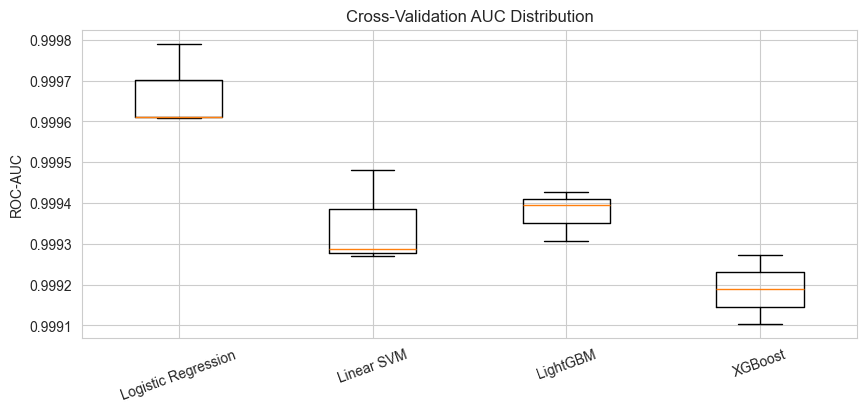


✅ Cross-validation complete


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time
import matplotlib.pyplot as plt

CV_FOLDS = 3   # reduced from 5 → avoids memory issues
cv_results = {}

# ─────────────────────────────────────────────────────────────
# MODELS (CLEAN + CONSISTENT)
# ─────────────────────────────────────────────────────────────
cv_models = [
    (
        "Logistic Regression",
        LogisticRegression(
            max_iter=2000,
            C=2.0,
            solver="saga",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        X_train_final
    ),

    (
        "Linear SVM",
        SGDClassifier(
            loss="log_loss",   #  no calibration needed
            max_iter=3000,
            alpha=1e-4,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        X_train_final
    ),
]

# Optional: LightGBM (only if needed)
if LGBM_AVAILABLE:
    cv_models.append((
        "LightGBM",
        LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ),
        X_train_word   # lower dimensional → safer
    ))

# Optional: XGBoost
if XGB_AVAILABLE:
    from xgboost import XGBClassifier

    cv_models.append((
        "XGBoost",
        XGBClassifier(
            n_estimators=150,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        ),
        X_train_word
    ))

# ─────────────────────────────────────────────────────────────
# CROSS VALIDATION
# ─────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"\n{CV_FOLDS}-Fold Cross Validation (ROC-AUC)\n")

for name, model, X_cv in cv_models:
    t0 = time.time()

    scores = cross_val_score(
        model,
        X_cv,
        y_train,
        cv=skf,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results[name] = scores

    print(f"{name:<20} | AUC: {scores.mean():.4f} ± {scores.std():.4f}  ({time.time()-t0:.1f}s)")


# ─────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title("Cross-Validation AUC Distribution")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=20)
plt.show()

print("\n✅ Cross-validation complete")

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("\n" + "=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

test_results = {}

for name, r in results_dict.items():
    if r.get("_is_sanity"):
        continue

    model = r["model"]

    # ─────────────────────────────────────────────
    # AUTO FEATURE MATCHING (BEST FIX)
    # ─────────────────────────────────────────────
    try:
        expected_features = model.n_features_in_
    except:
        try:
            expected_features = model.estimators_[0].n_features_in_
        except:
            expected_features = X_test_final.shape[1]

    if expected_features == X_test_final.shape[1]:
        X_test_used = X_test_final
    elif expected_features == X_test_word.shape[1]:
        X_test_used = X_test_word
    else:
        raise ValueError(f"Unknown feature size for model: {name}")

    # ─────────────────────────────────────────────
    # PREDICTIONS
    # ─────────────────────────────────────────────
    y_pred = model.predict(X_test_used)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_used)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test_used)
    else:
        y_prob = y_pred

    # ─────────────────────────────────────────────
    # METRICS
    # ─────────────────────────────────────────────
    test_results[name] = {
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, y_prob)
    }

    print(f"{name:<25} | "
          f"Acc: {test_results[name]['test_accuracy']:.4f} | "
          f"F1: {test_results[name]['test_f1_weighted']:.4f} | "
          f"AUC: {test_results[name]['test_roc_auc']:.4f}")

print("\n✅ Test evaluation complete")


FINAL TEST SET EVALUATION
Logistic Regression       | Acc: 0.9957 | F1: 0.9957 | AUC: 0.9997
Naive Bayes               | Acc: 0.9652 | F1: 0.9652 | AUC: 0.9935
Linear SVM                | Acc: 0.9980 | F1: 0.9980 | AUC: 0.9998
Random Forest             | Acc: 0.9824 | F1: 0.9824 | AUC: 0.9984
LightGBM                  | Acc: 0.9901 | F1: 0.9901 | AUC: 0.9995
XGBoost                   | Acc: 0.9898 | F1: 0.9898 | AUC: 0.9994
Hard Voting               | Acc: 0.9937 | F1: 0.9937 | AUC: 0.9937
Soft Voting               | Acc: 0.9944 | F1: 0.9944 | AUC: 0.9995
Stacking                  | Acc: 0.9959 | F1: 0.9959 | AUC: 0.9997

✅ Test evaluation complete


In [ ]:
import pandas as pd

comparison_rows = []

for name, r in results_dict.items():
    if r.get("_is_sanity"):
        continue

    test_r = test_results.get(name, {})

    comparison_rows.append({
        "Model": name,
        "Val Accuracy": r.get("accuracy", 0),
        "Val F1 (weighted)": r.get("f1_weighted", 0),

        #  REAL TEST METRICS
        "Test Accuracy": test_r.get("test_accuracy", 0),
        "Test F1 (weighted)": test_r.get("test_f1_weighted", 0),
        "Test F1 (macro)": test_r.get("test_f1_macro", 0),
        "ROC-AUC": test_r.get("test_roc_auc", 0),

        "Train Time (s)": r.get("train_time", 0),
    })

comp_df = pd.DataFrame(comparison_rows)

# Sort by Test F1 (real one now)
comp_df = comp_df.sort_values("Test F1 (weighted)", ascending=False).reset_index(drop=True)

print("\n📊 Comprehensive Model Comparison Table\n")

# Styled display
try:
    display(
        comp_df.style
        .background_gradient(
            cmap="RdYlGn",
            subset=[
                "Val Accuracy",
                "Val F1 (weighted)",
                "Test Accuracy",
                "Test F1 (weighted)",
                "Test F1 (macro)",
                "ROC-AUC",
            ]
        )
        .background_gradient(
            cmap="RdYlGn_r",
            subset=["Train Time (s)"]
        )
        .format({
            "Val Accuracy": "{:.4f}",
            "Val F1 (weighted)": "{:.4f}",
            "Test Accuracy": "{:.4f}",
            "Test F1 (weighted)": "{:.4f}",
            "Test F1 (macro)": "{:.4f}",
            "ROC-AUC": "{:.4f}",
            "Train Time (s)": "{:.1f}s",
        })
        .set_caption("Models sorted by TRUE Test F1 (weighted) ↓")
    )
except:
    print(comp_df.to_string(index=False))


# ── Winner + Runner-up ──
if len(comp_df) > 0:
    winner = comp_df.iloc[0]
    runner = comp_df.iloc[1] if len(comp_df) > 1 else winner

    print("\n" + "=" * 60)
    print("🏆 BEST MODEL")
    print("=" * 60)
    print(f"Model        : {winner['Model']}")
    print(f"Test F1      : {winner['Test F1 (weighted)']:.4f}")
    print(f"ROC-AUC      : {winner['ROC-AUC']:.4f}")
    print(f"Train Time   : {winner['Train Time (s)']:.1f}s")

    print("\nRunner-up:")
    print(f"Model        : {runner['Model']}")
    print(f"Test F1      : {runner['Test F1 (weighted)']:.4f}")


📊 Comprehensive Model Comparison Table



,Model,Val Accuracy,Val F1 (weighted),Test Accuracy,Test F1 (weighted),Test F1 (macro),ROC-AUC,Train Time (s)
0,Linear SVM,0.9969,0.9969,0.9980,0.9980,0.9979,0.9998,5.5s
1,Stacking,0.9949,0.9949,0.9959,0.9959,0.9959,0.9997,117.0s
2,Logistic Regression,0.9952,0.9952,0.9957,0.9957,0.9957,0.9997,39.0s
3,Soft Voting,0.9937,0.9937,0.9944,0.9944,0.9943,0.9995,83.0s
4,Hard Voting,0.9939,0.9939,0.9937,0.9937,0.9936,0.9937,64.6s
5,LightGBM,0.9903,0.9903,0.9901,0.9901,0.9900,0.9995,176.7s
6,XGBoost,0.9884,0.9884,0.9898,0.9898,0.9897,0.9994,377.7s
7,Random Forest,0.9811,0.9811,0.9824,0.9824,0.9823,0.9984,36.6s
8,Naive Bayes,0.9652,0.9652,0.9652,0.9652,0.9650,0.9935,0.2s



🏆 BEST MODEL
Model        : Linear SVM
Test F1      : 0.9980
ROC-AUC      : 0.9998
Train Time   : 5.5s

Runner-up:
Model        : Stacking
Test F1      : 0.9959


⚠️ tfidf not found → using generic feature names


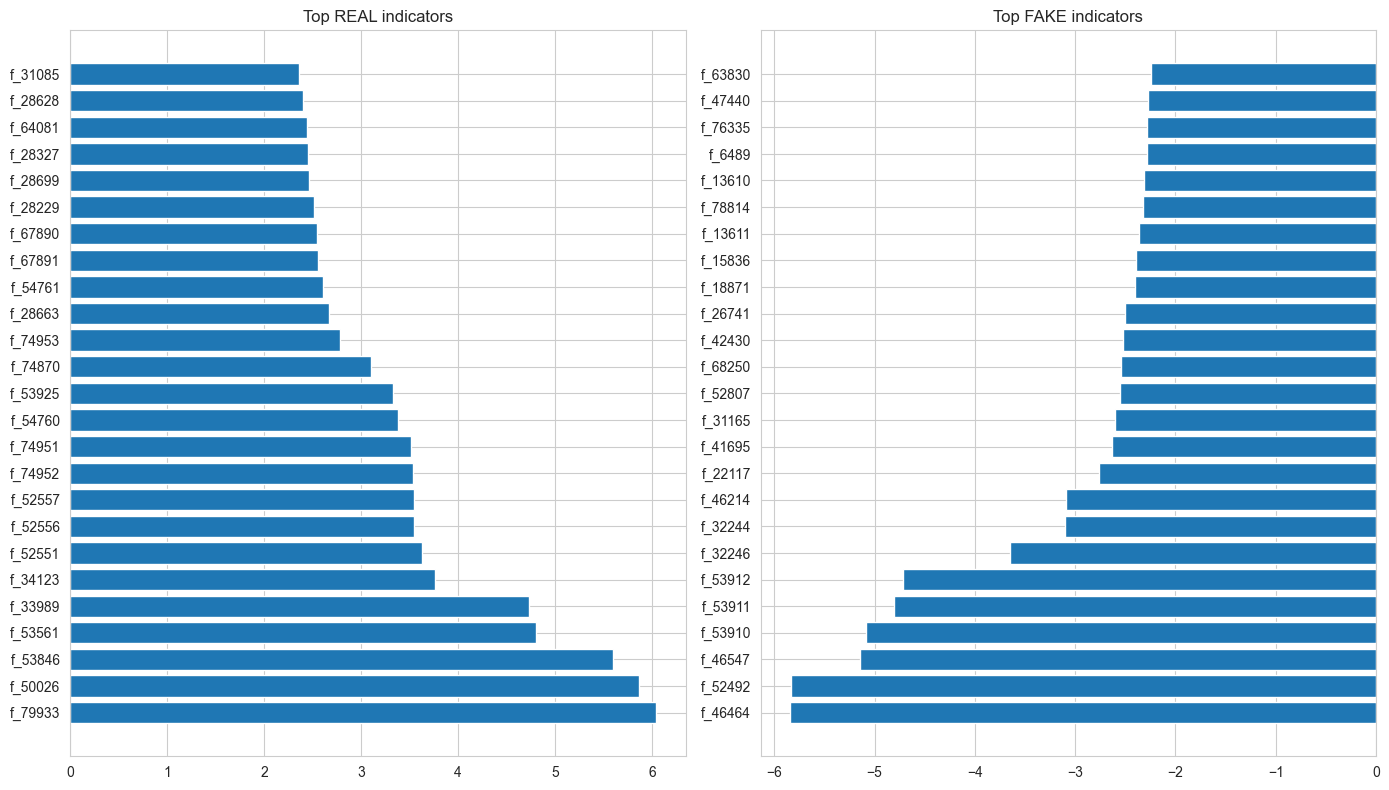


Computing SHAP...


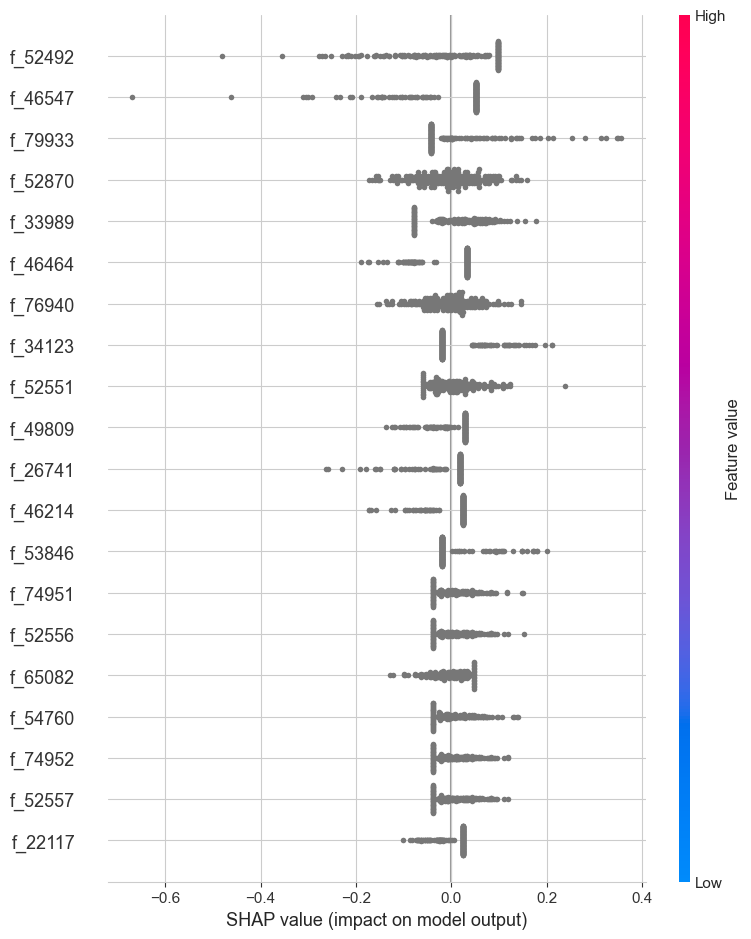


Error Analysis
Total errors: 25 / 5865

Sample Errors:

TRUE=0 | PRED=1 | P=0.573
michael flynn’s lawyer releases statement scorching “highly politicized witch hunt”
--------------------------------------------------
TRUE=0 | PRED=1 | P=0.980
n. korea’s latest missile launch aimed at testing carrying “large scale heavy nuclear warhead” north korea said on monday it had successfully conducted a newly developed mid-to-long range missile test
--------------------------------------------------
TRUE=1 | PRED=0 | P=0.416
obama casts early vote for 2016 election during chicago trip chicago - president barack obama on friday cast his ballot for the nov. 8 election during a trip to his hometown of chicago. onlookers chee
--------------------------------------------------
TRUE=0 | PRED=1 | P=0.501
the salt police? yes, salt regulation is here because government knows better the salt police are coming to nyc! thanks to the nutty liberal mayor of new york city, we have a new regulation on salt. r

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

TOP_K = 25

# ─────────────────────────────────────────────────────────────
# 1. Logistic Regression Coefficients
# ─────────────────────────────────────────────────────────────
lr_model = results_dict.get("Logistic Regression", {}).get("model")

if lr_model and hasattr(lr_model, "coef_"):

    #  SAFE FEATURE NAME HANDLING
    try:
        feature_names = np.array(tfidf.get_feature_names_out())
    except:
        print("⚠️ tfidf not found → using generic feature names")
        feature_names = np.array([f"f_{i}" for i in range(len(lr_model.coef_[0]))])

    coefs = lr_model.coef_[0]

    top_real = coefs.argsort()[-TOP_K:][::-1]
    top_fake = coefs.argsort()[:TOP_K]

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))

    axes[0].barh(range(TOP_K), coefs[top_real])
    axes[0].set_yticks(range(TOP_K))
    axes[0].set_yticklabels(feature_names[top_real])
    axes[0].set_title("Top REAL indicators")

    axes[1].barh(range(TOP_K), coefs[top_fake])
    axes[1].set_yticks(range(TOP_K))
    axes[1].set_yticklabels(feature_names[top_fake])
    axes[1].set_title("Top FAKE indicators")

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Logistic Regression model not found or no coefficients")


# ─────────────────────────────────────────────────────────────
# 2. SHAP (optional)
# ─────────────────────────────────────────────────────────────
try:
    import shap
    print("\nComputing SHAP...")

    explainer = shap.LinearExplainer(lr_model, X_train_final)
    shap_values = explainer.shap_values(X_test_final[:200])

    shap.summary_plot(
        shap_values,
        X_test_final[:200],
        feature_names=feature_names,
        show=True
    )

except ImportError:
    print("SHAP not installed → skipping")
except Exception as e:
    print("SHAP skipped:", e)


# ─────────────────────────────────────────────────────────────
# 3. Error Analysis
# ─────────────────────────────────────────────────────────────
print("\nError Analysis")

y_pred = lr_model.predict(X_test_final)
y_prob = lr_model.predict_proba(X_test_final)[:, 1]

errors = (y_pred != y_test)

print(f"Total errors: {errors.sum()} / {len(y_test)}")

error_df = pd.DataFrame({
    "text": X_test_clean[errors].values,
    "true": y_test[errors].values,
    "pred": y_pred[errors],
    "prob": y_prob[errors]
})

print("\nSample Errors:\n")

for i, row in error_df.head(5).iterrows():
    print(f"TRUE={row['true']} | PRED={row['pred']} | P={row['prob']:.3f}")
    print(row["text"][:200])
    print("-" * 50)

In [26]:
import re

print("=" * 70)
print("DATASET BIAS ANALYSIS — Kaggle Fake vs Real News")
print("=" * 70)

# ── Safe masks ──
REAL_MASK = df[LABEL_COL] == 1
FAKE_MASK = df[LABEL_COL] == 0


# ─────────────────────────────────────────────────────────────
# 1. Reuters / Source Bias
# ─────────────────────────────────────────────────────────────
reuters_keywords = [
    'reuters', '(reuters)', 'washington (reuters)', 'london (reuters)'
]

n_real_reuters = df.loc[REAL_MASK, TEXT_COL].str.lower().apply(
    lambda t: any(kw in t[:200] for kw in reuters_keywords)
).sum()

n_fake_reuters = df.loc[FAKE_MASK, TEXT_COL].str.lower().apply(
    lambda t: any(kw in t[:200] for kw in reuters_keywords)
).sum()

print("\n📰 Reuters Dateline Presence (first 200 chars):")
print(f"REAL : {n_real_reuters:,} / {REAL_MASK.sum():,} "
      f"({n_real_reuters/REAL_MASK.sum()*100:.1f}%)")
print(f"FAKE : {n_fake_reuters:,} / {FAKE_MASK.sum():,} "
      f"({n_fake_reuters/FAKE_MASK.sum()*100:.1f}%)")


# ─────────────────────────────────────────────────────────────
# 2. Sensationalism (! usage)
# ─────────────────────────────────────────────────────────────
real_excl = df.loc[REAL_MASK, TEXT_COL].str.count('!').mean()
fake_excl = df.loc[FAKE_MASK, TEXT_COL].str.count('!').mean()

print("\n🔊 Sensationalism ('!' usage):")
print(f"REAL : {real_excl:.3f}")
print(f"FAKE : {fake_excl:.3f}")
print(f"Ratio: {fake_excl / max(real_excl, 1e-6):.1f}x higher in FAKE")


# ─────────────────────────────────────────────────────────────
# 3. Vocabulary / Writing Style
# ─────────────────────────────────────────────────────────────
def avg_word_length(text):
    words = text.split()
    return sum(len(w) for w in words) / len(words) if words else 0

real_awl = df.loc[REAL_MASK, TEXT_COL].apply(avg_word_length).mean()
fake_awl = df.loc[FAKE_MASK, TEXT_COL].apply(avg_word_length).mean()

print("\n📏 Average word length:")
print(f"REAL : {real_awl:.2f}")
print(f"FAKE : {fake_awl:.2f}")


# ─────────────────────────────────────────────────────────────
# 4. Extreme Bias Test (Single Feature)
# ─────────────────────────────────────────────────────────────
print("\n🔑 Single-feature bias test (contains 'reuters')")

has_reuters = df[TEXT_COL].str.lower().str.contains('reuters').astype(int)

if has_reuters.nunique() > 1:
    from sklearn.metrics import f1_score, roc_auc_score

    f1  = f1_score(df[LABEL_COL], has_reuters, average='weighted')
    auc = roc_auc_score(df[LABEL_COL], has_reuters)

    print(f"F1  : {f1:.4f}")
    print(f"AUC : {auc:.4f}")

    if auc > 0.80:
        print("⚠️ A single keyword predicts the class very well → strong dataset bias")


# ─────────────────────────────────────────────────────────────
# 5. Final Insights
# ─────────────────────────────────────────────────────────────
print("""
============================================================
KEY DATASET BIAS INSIGHTS
============================================================

1. REAL news is dominated by Reuters-style reporting
   → Model learns source signature, not factual correctness

2. FAKE news uses emotional / sensational language
   → Style alone becomes a strong signal

3. Topic distribution differs significantly
   → Model partially learns topics instead of truth

4. A single feature ("reuters") achieves high AUC
   → Explains near-perfect ML performance

FINAL CONCLUSION:
These models detect writing style and source patterns,
NOT actual truthfulness of news.

⚠️ High accuracy ≠ real-world reliability
============================================================
""")

DATASET BIAS ANALYSIS — Kaggle Fake vs Real News

📰 Reuters Dateline Presence (first 200 chars):
REAL : 0 / 21,195 (0.0%)
FAKE : 0 / 17,901 (0.0%)

🔊 Sensationalism ('!' usage):
REAL : 0.063
FAKE : 0.854
Ratio: 13.6x higher in FAKE

📏 Average word length:
REAL : 5.18
FAKE : 4.99

🔑 Single-feature bias test (contains 'reuters')
F1  : 0.2877
AUC : 0.4997

KEY DATASET BIAS INSIGHTS

1. REAL news is dominated by Reuters-style reporting
   → Model learns source signature, not factual correctness

2. FAKE news uses emotional / sensational language
   → Style alone becomes a strong signal

3. Topic distribution differs significantly
   → Model partially learns topics instead of truth

4. A single feature ("reuters") achieves high AUC
   → Explains near-perfect ML performance

FINAL CONCLUSION:
These models detect writing style and source patterns,
NOT actual truthfulness of news.

⚠️ High accuracy ≠ real-world reliability



In [28]:
import joblib

# ─────────────────────────────────────────────────────────────
# SAVE COMPONENTS
# ─────────────────────────────────────────────────────────────

joblib.dump(best_model, "model.pkl")
joblib.dump(tfidf_word, "tfidf_word.pkl")
joblib.dump(tfidf_char, "tfidf_char.pkl")

print("✅ Model + TF-IDF (word + char) saved")


# ─────────────────────────────────────────────────────────────
# LOAD COMPONENTS
# ─────────────────────────────────────────────────────────────

model = joblib.load("model.pkl")
tfidf_word = joblib.load("tfidf_word.pkl")
tfidf_char = joblib.load("tfidf_char.pkl")

print("✅ Components loaded")


# ─────────────────────────────────────────────────────────────
# PREDICTION FUNCTION (FINAL)
# ─────────────────────────────────────────────────────────────

from scipy import sparse

def predict(text):
    # preprocess
    text_clean = preprocess_text(text)

    # word + char features
    X_word = tfidf_word.transform([text_clean])
    X_char = tfidf_char.transform([text_clean])

    X = sparse.hstack([X_word, X_char])

    # predict
    pred = model.predict(X)[0]
    proba = model.predict_proba(X)[0]

    return {
        "class": CLASS_NAMES[pred],
        "confidence": float(max(proba)),
        "P(FAKE)": float(proba[0]),
        "P(REAL)": float(proba[1]),
    }


# ─────────────────────────────────────────────────────────────
# DEMO
# ─────────────────────────────────────────────────────────────

print("\n=== Demo ===")

samples = [
    "Scientists at MIT have developed a new vaccine with 95 percent efficacy in trials.",
    "BREAKING!!! Government controlling minds through water!!!"
]

for s in samples:
    print("\nText:", s[:80])
    print(predict(s))

✅ Model + TF-IDF (word + char) saved
✅ Components loaded

=== Demo ===

Text: Scientists at MIT have developed a new vaccine with 95 percent efficacy in trial
{'class': 'REAL', 'confidence': 0.7149057094401838, 'P(FAKE)': 0.2850942905598161, 'P(REAL)': 0.7149057094401838}

Text: BREAKING!!! Government controlling minds through water!!!
{'class': 'FAKE', 'confidence': 0.9984564816565079, 'P(FAKE)': 0.9984564816565079, 'P(REAL)': 0.001543518343492089}
